In [1]:
import pandas as pd 
import numpy as np 
import os 
import json 
import sys 

In [2]:
path_to_recs = "../../../data/conv-trs/ecir-2026/rec-llm"

In [57]:
path_to_filter = "../../../data/conv-trs/ecir-2026/selected_queries/filtered_queries.json"

configs = pd.read_json(path_to_filter)['query_id']

In [61]:
# extract city counts 

cities = gpt_f['rec_cities'].explode().apply(lambda x: x['city'])
city_counts = cities.value_counts()

In [62]:
city_counts

rec_cities
Ljubljana     46
Porto         33
Lisbon        29
Bratislava    24
Ghent         23
              ..
Dresden        1
Trondheim      1
Zermatt        1
Nijmegen       1
Lecce          1
Name: count, Length: 88, dtype: int64

In [63]:
CITY_COORDINATES = {
    # Western Europe
    "Paris, France": [48.8566, 2.3522],
    "London, United Kingdom": [51.5074, -0.1278],
    "Amsterdam, Netherlands": [52.3676, 4.9041],
    "Brussels, Belgium": [50.8503, 4.3517],
    "Luxembourg City, Luxembourg": [49.6116, 6.1319],
    "Bruges, Belgium": [51.2093, 3.2247],
    "Ghent, Belgium": [51.0543, 3.7174],
    "Rotterdam, Netherlands": [51.9225, 4.4792],
    "Utrecht, Netherlands": [52.0907, 5.1214],
    "Maastricht, Netherlands": [50.8514, 5.6909],
    "Nijmegen, Netherlands": [51.8426, 5.8523],
    # France
    "Marseille, France": [43.2965, 5.3698],
    "Lyon, France": [45.7640, 4.8357],
    "Toulouse, France": [43.6047, 1.4442],
    "Nice, France": [43.7102, 7.2620],
    "Bordeaux, France": [44.8378, -0.5792],
    "Nantes, France": [47.2184, -1.5536],
    # Germany
    "Berlin, Germany": [52.5200, 13.4050],
    "Munich, Germany": [48.1351, 11.5820],
    "Frankfurt, Germany": [50.1109, 8.6821],
    "Cologne, Germany": [50.9375, 6.9603],
    "Leipzig, Germany": [51.3397, 12.3731],
    "Dresden, Germany": [51.0504, 13.7373],
    "Freiburg, Germany": [47.9990, 7.8421],
    # United Kingdom & Ireland
    "Edinburgh, Scotland": [55.9533, -3.1883],
    "Edinburgh, United Kingdom": [55.9533, -3.1883],
    "Dublin, Ireland": [53.3498, -6.2603],
    "Glasgow, United Kingdom": [55.8642, -4.2518],
    "Liverpool, United Kingdom": [53.4084, -2.9916],
    "Birmingham, United Kingdom": [52.4862, -1.8904],
    "Cork, Ireland": [51.8969, -8.4863],
    "Killarney, Ireland": [52.0586, -9.5047],
    # Scandinavia
    "Copenhagen, Denmark": [55.6761, 12.5683],
    "Stockholm, Sweden": [59.3293, 18.0686],
    "Oslo, Norway": [59.9139, 10.7522],
    "Helsinki, Finland": [60.1699, 24.9384],
    "Reykjavik, Iceland": [64.1466, -21.9426],
    "Bergen, Norway": [60.3913, 5.3221],
    "Gothenburg, Sweden": [57.7089, 11.9746],
    "Trondheim, Norway": [63.4305, 10.3951],
    "Turku, Finland": [60.4518, 22.2666],
    # Iberian Peninsula
    "Barcelona, Spain": [41.3851, 2.1734],
    "Madrid, Spain": [40.4168, -3.7038],
    "Valencia, Spain": [39.4699, -0.3763],
    "Seville, Spain": [37.3891, -5.9845],
    "Lisbon, Portugal": [38.7223, -9.1393],
    "Porto, Portugal": [41.1579, -8.6291],
    "Bilbao, Spain": [43.2630, -2.9350],
    "San Sebastian, Spain": [43.3183, -1.9812],
    "San Sebastián, Spain": [43.3183, -1.9812],
    "Córdoba, Spain": [37.8882, -4.7794],
    "Palma de Mallorca, Spain": [39.5696, 2.6502],
    "Ibiza, Spain": [38.9067, 1.4206],
    "Alicante, Spain": [38.3452, -0.4810],
    "Girona, Spain": [41.9794, 2.8214],
    "Guimarães, Portugal": [41.4450, -8.2915],
    "Ponta Delgada, Portugal": [37.7412, -25.6756],
    # Italy
    "Rome, Italy": [41.9028, 12.4964],
    "Florence, Italy": [43.7696, 11.2558],
    "Venice, Italy": [45.4408, 12.3155],
    "Milan, Italy": [45.4642, 9.1900],
    "Naples, Italy": [40.8518, 14.2681],
    "Turin, Italy": [45.0703, 7.6869],
    "Bologna, Italy": [44.4949, 11.3426],
    "Palermo, Italy": [38.1157, 13.3615],
    "Genoa, Italy": [44.4056, 8.9463],
    "Cagliari, Italy": [39.2238, 9.1217],
    "Catania, Italy": [37.5079, 15.0830],
    "Lecce, Italy": [40.3515, 18.1750],
    "Trieste, Italy": [45.6495, 13.7768],
    "Lake Como, Italy": [45.9980, 9.2661],
    # Central Europe
    "Vienna, Austria": [48.2082, 16.3738],
    "Prague, Czech Republic": [50.0755, 14.4378],
    "Budapest, Hungary": [47.4979, 19.0402],
    "Bratislava, Slovakia": [48.1486, 17.1077],
    "Salzburg, Austria": [47.8095, 13.0550],
    "Graz, Austria": [47.0707, 15.4395],
    "Innsbruck, Austria": [47.2692, 11.4041],
    "Brno, Czech Republic": [49.1951, 16.6068],
    # Switzerland
    "Zurich, Switzerland": [47.3769, 8.5417],
    "Bern, Switzerland": [46.9480, 7.4474],
    "Geneva, Switzerland": [46.2044, 6.1432],
    "Basel, Switzerland": [47.5596, 7.5886],
    "Lucerne, Switzerland": [47.0502, 8.3093],
    "Interlaken, Switzerland": [46.6863, 7.8632],
    "Zermatt, Switzerland": [46.0207, 7.7491],
    # Eastern Europe
    "Warsaw, Poland": [52.2297, 21.0122],
    "Krakow, Poland": [50.0647, 19.9450],
    "Gdansk, Poland": [54.3520, 18.6466],
    "Poznań, Poland": [52.4064, 16.9252],
    "Toruń, Poland": [53.0138, 18.5984],
    "Bucharest, Romania": [44.4268, 26.1025],
    "Cluj-Napoca, Romania": [46.7712, 23.6236],
    "Timișoara, Romania": [45.7489, 21.2087],
    "Sofia, Bulgaria": [42.6977, 23.3219],
    "Plovdiv, Bulgaria": [42.1354, 24.7453],
    # Balkans
    "Belgrade, Serbia": [44.7866, 20.4489],
    "Ljubljana, Slovenia": [46.0569, 14.5058],
    "Zagreb, Croatia": [45.8150, 15.9819],
    "Split, Croatia": [43.5081, 16.4402],
    "Dubrovnik, Croatia": [42.6507, 18.0944],
    "Plitvice, Croatia": [44.8654, 15.5820],
    "Sarajevo, Bosnia and Herzegovina": [43.8563, 18.4131],
    "Mostar, Bosnia and Herzegovina": [43.3438, 17.8078],
    "Skopje, North Macedonia": [41.9973, 21.4280],
    "Tirana, Albania": [41.3275, 19.8187],
    "Berat, Albania": [40.7058, 19.9522],
    "Novi Sad, Serbia": [45.2671, 19.8335],
    # Baltic States
    "Riga, Latvia": [56.9496, 24.1052],
    "Vilnius, Lithuania": [54.6872, 25.2797],
    "Kaunas, Lithuania": [54.8985, 23.9036],
    "Tallinn, Estonia": [59.4370, 24.7536],
    # Greece
    "Athens, Greece": [37.9838, 23.7275],
    "Thessaloniki, Greece": [40.6401, 22.9444],
    "Santorini, Greece": [36.3932, 25.4615],
    # Other
    "Malta, Malta": [35.8989, 14.5146],
    "Valletta, Malta": [35.8989, 14.5146],
    "Nicosia, Cyprus": [35.1856, 33.3823],
    "Kyiv, Ukraine": [50.4501, 30.5234],
    "Lviv, Ukraine": [49.8397, 24.0297],
    "Tbilisi, Georgia": [41.7151, 44.8271],
  }

In [64]:
converted_city_coords = {}

for item in CITY_COORDINATES: 
    city,country = item.split(", ")
    converted_city_coords[city] = {
        'country': country, 
        'coordinates': CITY_COORDINATES[item]
    }

In [65]:
# with open("city_coords.json", "w+") as f: 
#     json.dump(converted_city_coords, f)

In [66]:
# check in World Cities DB 

world_cities = pd.read_csv("worldcities.csv")

In [67]:
kb_cities = pd.read_csv("../../../data/conv-trs/eu_cities.csv")['city']

In [68]:
unmapped_cities = []
for city in cities.unique(): 
    if city not in converted_city_coords: 
        if city not in world_cities['city']:
            if city not in kb_cities:
                unmapped_cities.append(city)

In [69]:
unmapped_cities

['Tartu']

In [70]:
countries = gpt_f['rec_cities'].explode().apply(lambda x: x['country'])
df = countries.value_counts().to_frame().reset_index()

In [71]:
df.head()

,rec_cities,count
0,Portugal,62
1,Slovenia,46
2,Spain,32
3,Austria,27
4,Poland,27


 Some insights regarding the diversity, cities in Portugal are recommended disproportionately higher than any other country. The count for Portugal is around 1450 and the next highest is Slovenia with 786... 

### Visualizing country diversity

In [78]:
def find_country_counts(model):
    
    results = pd.read_json(f"{path_to_recs}/{model}_recommendations.json")
    results_f = results[results['query_id'].isin(configs)]
    countries = results_f['rec_cities'].explode().apply(lambda x: x['country'])
    df = countries.value_counts().to_frame().reset_index()

    return df

In [88]:
import matplotlib.pyplot as plt
import geopandas as gpd

def plot_map(counts_df, recllm='', ax=None):
    world = gpd.read_file("110m_cultural/ne_110m_admin_0_countries.shp")
    europe = world[world['CONTINENT'] == 'Europe']

    counts_df.columns = ['rec_city', 'count']

    # Merge with GeoDataFrame
    europe = europe.merge(
        counts_df,
        left_on='SOVEREIGNT',
        right_on='rec_city',
        how='left'
    )

    # Plot on provided axis
    europe.plot(
        column='count',
        cmap='YlOrRd',
        linewidth=0.8,
        edgecolor='gray',
        legend=True,
        ax=ax
    )

    ax.set_title(f'Geographical Diversity of RecLLM Results - {recllm}', fontsize=12)
    ax.axis('off')


In [93]:
def run():
    models = [{
            'name': 'V1.L1',
            'model': 'gemini_2_5_flash'
        },  
        {
            'name': 'V1.L2',
            'model': 'gpt_4o'
        }, 
        {
            'name': 'V2.L1',
            'model': 'claude_4_sonnet'
        }, 
        {
            'name': 'V2.L2',
            'model': 'qwen_3_next_80b'
    }]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()  # flatten to 1D array

    for i, model in enumerate(models):
        count_df = find_country_counts(model['model'])
        plot_map(count_df, model['name'], ax=axes[i])

    # Remove any unused subplots (if fewer than 4)
    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(f"../../../plots/heatmap.pdf", bbox_inches='tight')
    plt.show()

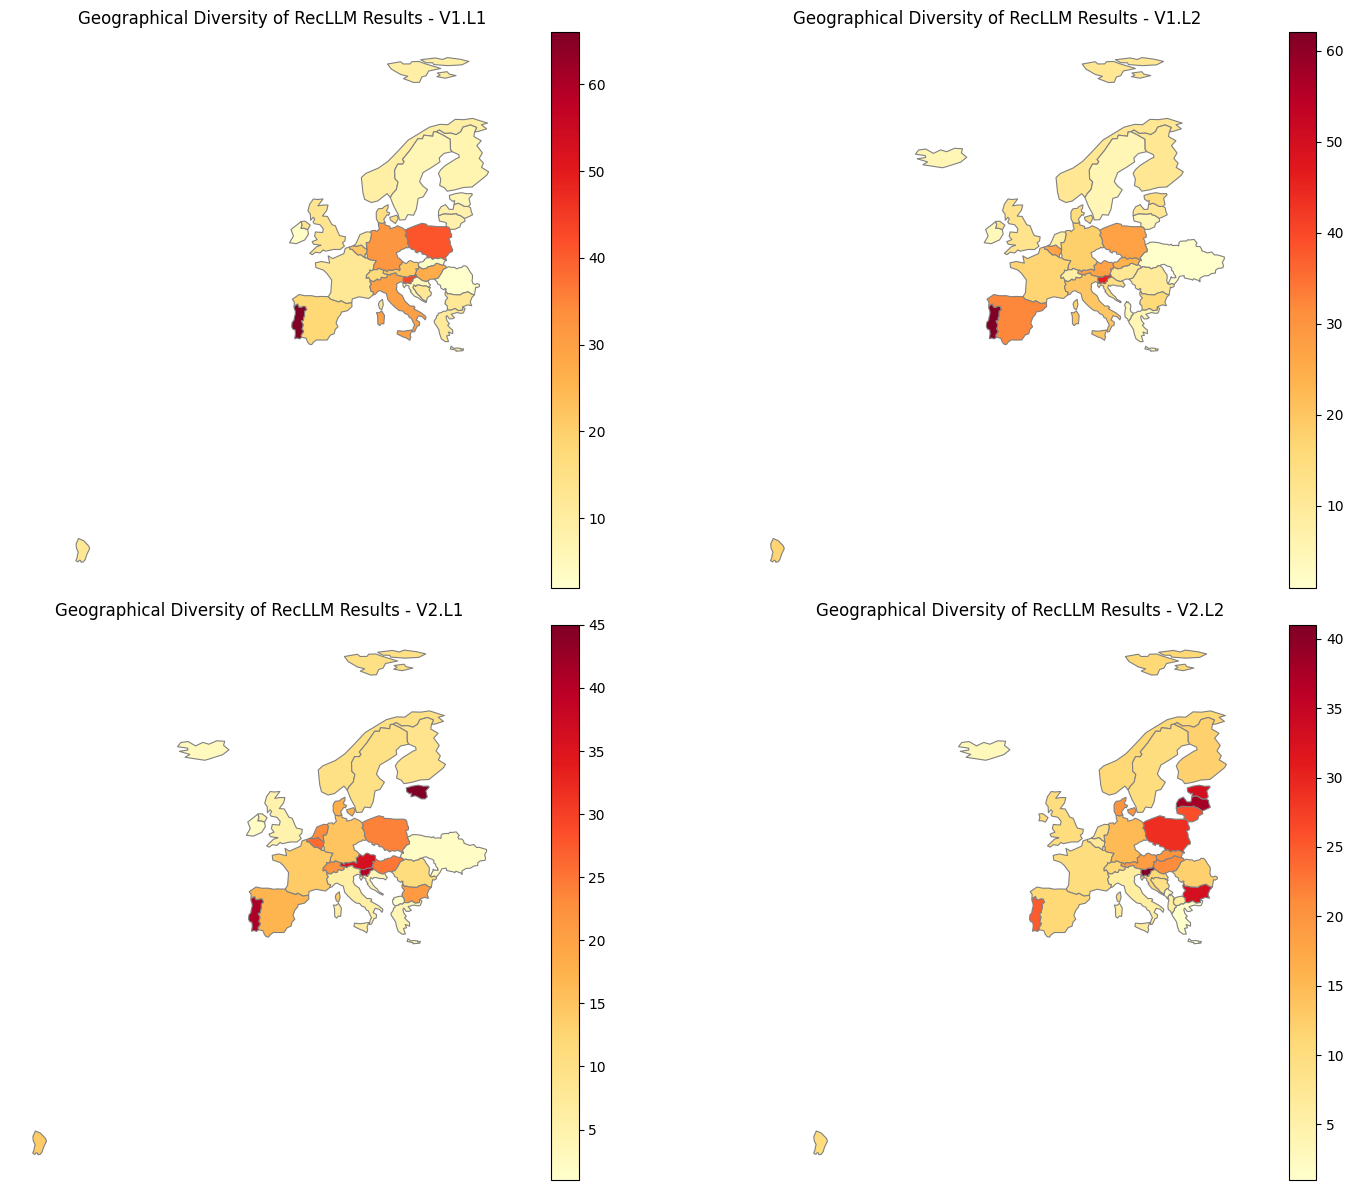

In [94]:
run()

In [95]:
def get_cities(model):
    
    results = pd.read_json(f"{path_to_recs}/{model}_recommendations.json")
    results_f = results[results['query_id'].isin(configs)]
    cities = results_f['rec_cities'].explode().apply(lambda x: x['city'])
    
    return set(cities)

In [97]:
models = [{
            'name': 'V1.L1',
            'model': 'gemini_2_5_flash'
        },  
        {
            'name': 'V1.L2',
            'model': 'gpt_4o'
        }, 
        {
            'name': 'V2.L1',
            'model': 'claude_4_sonnet'
        }, 
        {
            'name': 'V2.L2',
            'model': 'qwen_3_next_80b'
    }]

cities = set()
for model in models:
    cities = cities.union(get_cities(model['model']))

print(set(cities))

{'Nijmegen', 'Palma', 'Stockholm', 'Riga', 'Palma de Mallorca', 'Trieste', 'Sarajevo', 'Belgrade', 'Maribor', 'Groningen', 'Sighisoara', 'Cagliari', 'Košice', 'Bordeaux', 'Paris', 'Osijek', 'Rome', 'San Sebastian', 'Freiburg im Breisgau', 'Düsseldorf', 'Coimbra', 'Strasbourg', 'Trier', 'Oslo', 'Kaunas', 'Budapest', 'Zermatt', 'Freiburg', 'Wrocław', 'Lviv', 'Cologne', 'Malmö', 'Salzburg', 'Berlin', 'Amsterdam', 'Cork', 'Rotterdam', 'Nancy', 'Novi Sad', 'Dresden', 'Killarney', 'Warsaw', 'Šibenik', 'Sofia', 'Vienna', 'Tartu', 'Bratislava', 'Interlaken', 'Debrecen', 'Córdoba', 'Dublin', 'Timisoara', 'Eindhoven', 'Berat', 'Hamburg', 'Lecce', 'Lisbon', 'Girona', 'Birmingham', 'Catania', 'Edinburgh', 'Gjirokastër', 'Timișoara', 'Bled', 'Porto', 'Seville', 'Cadiz', 'Cluj-Napoca', 'Banská Štiavnica', 'Dubrovnik', 'Brno', 'Venice', 'Barcelona', 'Bologna', 'Florence', 'Salamanca', 'Zagreb', 'Krakow', 'Turku', 'Glasgow', 'Malta', 'Chania', 'Aarhus', 'Bern', 'Gijón', 'Copenhagen', 'Lille', 'Brašov'